# 10.1.注意力提示

感谢读者对本书的关注，因为读者的注意力是一种稀缺的资源： 此刻读者正在阅读本书（而忽略了其他的书）， 因此读者的注意力是用机会成本（与金钱类似）来支付的。 为了确保读者现在投入的注意力是值得的， 作者们尽全力（全部的注意力）创作一本好书。

自经济学研究稀缺资源分配以来，人们正处在"注意力经济"时代， 即人类的注意力被视为可以交换的、有限的、有价值的且稀缺的商品。 许多商业模式也被开发出来去利用这一点： 在音乐或视频流媒体服务上，人们要么消耗注意力在广告上，要么付钱来隐藏广告； 为了在网络游戏世界的成长，人们要么消耗注意力在游戏战斗中， 从而帮助吸引新的玩家，要么付钱立即变得强大。 总之，注意力不是免费的。

注意力是稀缺的，而环境中的干扰注意力的信息却并不少。 比如人类的视觉神经系统大约每秒收到$10^8$位的信息， 这远远超过了大脑能够完全处理的水平。 幸运的是，人类的祖先已经从经验（也称为数据）中认识到 "并非感官的所有输入都是一样的"。 在整个人类历史中，这种只将注意力引向感兴趣的一小部分信息的能力， 使人类的大脑能够更明智地分配资源来生存、成长和社交， 例如发现天敌、找寻食物和伴侣。

## 10.1.1.环境配置

本节仅使用 PyTorch + Matplotlib 可视化注意力权重，不涉及 pypto 算子与 NPU 设备，因此不需要进行 NPU 初始化。`show_heatmaps` 是后续各节（[10.2 节](10.02_nadaraya_waston.ipynb)起的模型可视化）都要复用的工具，本节将内联其完整实现，该实现同时收录在 `src/utils.py` 中，供后续各节直接导入复用。

In [ ]:
%pip install torch matplotlib

import matplotlib.pyplot as plt
import torch

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
import torch
from d2l import torch as d2l
    </pre>
  </div>
</details>

## 10.1.2.生物学中的注意力提示

注意力是如何应用于视觉世界中的呢？ 这要从当今十分普及的*双组件*（two-component）的框架开始讲起： 这个框架的出现可以追溯到19世纪90年代的威廉·詹姆斯， 他被认为是"美国心理学之父" ([James, 2007](https://zh.d2l.ai/chapter_references/zreferences.html#James.2007))。 在这个框架中，受试者基于*非自主性提示*和*自主性提示* 有选择地引导注意力的焦点。

非自主性提示是基于环境中物体的突出性和易见性。 想象一下，假如我们面前有五个物品： 一份报纸、一篇研究论文、一杯咖啡、一本笔记本和一本书， 就像 图10.1.1。 所有纸制品都是黑白印刷的，但咖啡杯是红色的。 换句话说，这个咖啡杯在这种视觉环境中是突出和显眼的， 不由自主地引起人们的注意。 所以我们会把视力最敏锐的地方放到咖啡上， 如 图10.1.1所示。

<div align="center">
  <img src="./images/eye-coffee.svg" alt="图10.1.1 由于突出性的非自主性提示（红杯子），注意力不自主地指向了咖啡杯" width="400">
  <br><small>图10.1.1 由于突出性的非自主性提示（红杯子），注意力不自主地指向了咖啡杯</small>
</div>

喝咖啡后，我们会变得兴奋并想读书， 所以转过头，重新聚焦眼睛，然后看看书， 就像 图10.1.2中描述那样。 与 图10.1.1中由于突出性导致的选择不同， 此时选择书是受到了认知和意识的控制， 因此注意力在基于自主性提示去辅助选择时将更为谨慎。 受试者的主观意愿推动，选择的力量也就更强大。

<div align="center">
  <img src="./images/eye-book.svg" alt="图10.1.2 依赖于任务的意志提示（想读一本书），注意力被自主引导到书上" width="400">
  <br><small>图10.1.2 依赖于任务的意志提示（想读一本书），注意力被自主引导到书上</small>
</div>

## 10.1.3.查询、键和值

自主性的与非自主性的注意力提示解释了人类的注意力的方式， 下面来看看如何通过这两种注意力提示， 用神经网络来设计注意力机制的框架，

首先，考虑一个相对简单的状况， 即只使用非自主性提示。 要想将选择偏向于感官输入， 则可以简单地使用参数化的全连接层， 甚至是非参数化的最大汇聚层或平均汇聚层。

因此，"是否包含自主性提示"将注意力机制与全连接层或汇聚层区别开来。 在注意力机制的背景下，自主性提示被称为*查询*（query）。 给定任何查询，注意力机制通过*注意力汇聚*（attention pooling） 将选择引导至*感官输入*（sensory inputs，例如中间特征表示）。 在注意力机制中，这些感官输入被称为*值*（value）。 更通俗的解释，每个值都与一个*键*（key）配对， 这可以想象为感官输入的非自主提示。 如 图10.1.3所示，可以通过设计注意力汇聚的方式， 便于给定的查询（自主性提示）与键（非自主性提示）进行匹配， 这将引导得出最匹配的值（感官输入）。

<div align="center">
  <img src="./images/qkv.svg" alt="图10.1.3 注意力机制通过注意力汇聚将查询（自主性提示）和键（非自主性提示）结合在一起，实现对值（感官输入）的选择倾向" width="400">
  <br><small>图10.1.3 注意力机制通过注意力汇聚将查询（自主性提示）和键（非自主性提示）结合在一起，实现对值（感官输入）的选择倾向</small>
</div>

鉴于上面所提框架在 图10.1.3中的主导地位， 因此这个框架下的模型将成为本章的中心。 然而，注意力机制的设计有许多替代方案。 例如可以设计一个不可微的注意力模型， 该模型可以使用强化学习方法 ([Mnih, Heess, Graves, ea, 2014](https://zh.d2l.ai/chapter_references/zreferences.html#Mnih.Heess.Graves.ea.2014))进行训练。

## 10.1.4.注意力的可视化

平均汇聚层可以被视为输入的加权平均值， 其中各输入的权重是一样的。 实际上，注意力汇聚得到的是加权平均的总和值， 其中权重是在给定的查询和不同的键之间计算得出的。

In [2]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap="Reds"):
    """显示矩阵热图"""
    matrices = matrices.detach().cpu().numpy()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix, cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles is not None:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6)
    plt.show()


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);
    </pre>
  </div>
</details>

为了可视化注意力权重，需要定义一个`show_heatmaps`函数。 其输入`matrices`的形状是 （要显示的行数，要显示的列数，查询的数目，键的数目）。实现与 d2l 原书的 `d2l.show_heatmaps` 一致：用 Matplotlib 的 `imshow` 绘制，颜色自动映射到数据的最小值与最大值，并附带 colorbar；`detach().cpu()` 统一将张量移至 CPU 后再绘制。


下面使用一个简单的例子进行演示。 在本例子中，仅当查询和键相同时，注意力权重为1，否则为0。

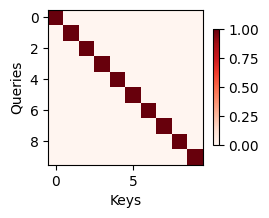

In [3]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')
    </pre>
  </div>
</details>

后面的章节内容将经常调用`show_heatmaps`函数来显示注意力权重。

## 10.1.5.小结

* 人类的注意力是有限的、有价值和稀缺的资源。
* 受试者使用非自主性和自主性提示有选择性地引导注意力。前者基于突出性，后者则依赖于意识。
* 注意力机制与全连接层或者汇聚层的区别源于增加的自主提示。
* 由于包含了自主性提示，注意力机制与全连接的层或汇聚层不同。
* 注意力机制通过注意力汇聚使选择偏向于值（感官输入），其中包含查询（自主性提示）和键（非自主性提示）。键和值是成对的。
* 可视化查询和键之间的注意力权重是可行的。

## 10.1.6.练习

1. 在机器翻译中通过解码序列词元时，其自主性提示可能是什么？非自主性提示和感官输入又是什么？
1. 随机生成一个$10 \times 10$矩阵并使用`softmax`运算来确保每行都是有效的概率分布，然后可视化输出注意力权重。

参考答案详见 [answers/10.01_reference_answer](./answers/10.01_reference_answer.ipynb)。

### 10.1.6.1.参考答案（PyTorch）

In [4]:
!cat answers/txt/10.01_reference_answer.txt